# Solutions · 01 · Generating random variates

Worked solutions to the exercises of [notebook 01](../notebooks/01_generating_random_variates.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from scipy import stats
from engstoch import rng as rg, rngtests as rt, special as sf
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Exercise 1

Generate standard Cauchy variates by inversion and by the ratio of two independent normals; show with a KS test that both are Cauchy, and show that the running mean of 10^6 of them does not converge.

inversion: KS p = 0.864;  ratio of normals: KS p = 0.686


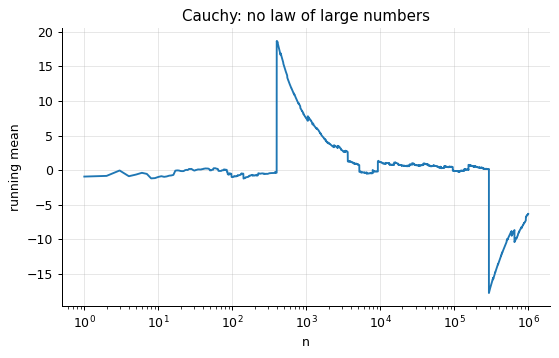

running mean at n = 1e4, 1e5, 1e6: [1.154, -0.114, -6.338]


In [2]:
g = R(1)
c_inv = np.tan(np.pi * (g.random(100_000) - 0.5))
c_rat = g.standard_normal(100_000) / g.standard_normal(100_000)
print(f"inversion: KS p = {stats.kstest(c_inv, 'cauchy').pvalue:.3f};  ratio of normals: KS p = {stats.kstest(c_rat, 'cauchy').pvalue:.3f}")
x = np.tan(np.pi * (R(2).random(10**6) - 0.5))
n = np.arange(1, len(x) + 1)
plt.semilogx(n, np.cumsum(x) / n); plt.xlabel("n"); plt.ylabel("running mean"); plt.title("Cauchy: no law of large numbers"); plt.show()
print("running mean at n = 1e4, 1e5, 1e6:", [round(float(np.mean(x[:k])), 3) for k in (10**4, 10**5, 10**6)])

Both constructions give the standard Cauchy law (F⁻¹(u) = tan(π(u − ½)); the ratio of two independent normals
is Cauchy because the angle of a 2-D normal vector is uniform). The Cauchy has no mean: the running mean keeps
jumping whenever a huge value arrives, and in fact the mean of n Cauchy variables is again standard Cauchy -
averaging does not help at all.

## Exercise 2

Sample the half-normal density sqrt(2/pi) exp(-x^2/2) on x > 0 by rejection from an Exp(lambda) proposal. Find the lambda that minimises M and check the observed acceptance rate against 1/M.

In [3]:
lams = np.linspace(0.3, 3, 271)
M = np.sqrt(2 / np.pi) / lams * np.exp(lams**2 / 2)        # max of f/g, attained at x = lambda
lam_best = lams[np.argmin(M)]
print(f"best lambda = {lam_best:.3f} (theory 1), M = {M.min():.4f} (sqrt(2e/pi) = {np.sqrt(2 * np.e / np.pi):.4f})")
f = lambda x: np.sqrt(2 / np.pi) * np.exp(-x**2 / 2)
r = rg.rejection(f, lambda m: R(3).exponential(1 / lam_best, m), lambda x: lam_best * np.exp(-lam_best * x), M.min() * 1.0001, R(4), 50_000)
print(f"observed acceptance {r['acceptance']:.4f} vs 1/M = {1 / M.min():.4f}; KS p vs half-normal = {stats.kstest(r['x'], 'halfnorm').pvalue:.3f}")

best lambda = 1.000 (theory 1), M = 1.3155 (sqrt(2e/pi) = 1.3155)
observed acceptance 0.7584 vs 1/M = 0.7602; KS p vs half-normal = 0.075


The ratio f/g = √(2/π) e^{−x²/2 + λx}/λ is maximal at x = λ, so M(λ) = √(2/π) e^{λ²/2}/λ, minimised at λ = 1 with
M = √(2e/π) ≈ 1.315: three proposals in four are accepted. Attaching a random sign gives a normal - one of
the classical exact normal generators.

## Exercise 3

**Implement it yourself:** write the Box-Muller transform and the polar method from scratch, time both for 10^6 normals, and test both with `rngtests.ks_test` against `special.norm_cdf`.

In [4]:
def box_muller_mine(g, n):
    u1, u2 = 1 - g.random(n // 2), g.random(n // 2)
    r = np.sqrt(-2 * np.log(u1))
    return np.r_[r * np.cos(2 * np.pi * u2), r * np.sin(2 * np.pi * u2)]
def polar_mine(g, n):
    out = []
    while len(out) < n:
        v = 2 * g.random((n, 2)) - 1
        s = np.sum(v**2, axis=1); ok = (s > 0) & (s < 1)
        out.extend((v[ok] * np.sqrt(-2 * np.log(s[ok]) / s[ok])[:, None]).ravel())
    return np.array(out[:n])
for name, fn in (("Box-Muller", box_muller_mine), ("polar", polar_mine)):
    t0 = time.perf_counter(); z = fn(R(5), 10**6); t1 = time.perf_counter() - t0
    print(f"{name:<10}: {t1 * 1000:.0f} ms for 1e6 normals, KS p = {rt.ks_test(z, sf.norm_cdf)['p_value']:.3f}, mean {z.mean():+.4f}, var {z.var():.4f}")

Box-Muller: 89 ms for 1e6 normals, KS p = 0.562, mean -0.0007, var 1.0006


polar     : 403 ms for 1e6 normals, KS p = 0.145, mean -0.0012, var 0.9983


In vectorised NumPy Box-Muller is several times faster: the polar method saves the trigonometric functions but
throws away 21 % of its uniforms and pays for boolean indexing and a Python-level loop. In compiled code the polar method used to win;
modern generators (NumPy's ziggurat) beat both by avoiding logarithms almost always.